In [28]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
folder = "./data/bitstream_surrogate/"
file_name1 = "bitstream_closed_loop_1.txt"
file_name2 = "bitstream_closed_loop_2.txt"

In [32]:
def data_read_bin(file_path):
    with open(file_path, 'r') as f:
        bitstream = f.read()
    return bitstream

def find_Prob(bitstream):
    bit_lst = [int(b) for b in bitstream[:]]
    print(f"Total No bits: {len(bit_lst)}")
    print(f"Probability of generated bits: {sum(bit_lst)/len(bit_lst):.4f}")


def prevspost_bit_grp(bitstream, grp_len):
    #convert it in to bit_grps
    bit_grp = []
    for i in range(int(len(bitstream)/grp_len)):
        bit_grp.append(bitstream[grp_len*i : grp_len*i + grp_len])
    pre_bit_grp = bit_grp[0::2]
    post_bit_grp = bit_grp[1::2]

    return pre_bit_grp, post_bit_grp

def transition_prob(pre_groups, post_groups):
    num_states = 2**len(pre_groups[0])
    transition_matrix = np.zeros((num_states, num_states), dtype=int)
    trans_prob = np.zeros((num_states, num_states), dtype=float)

    # Create labels for the axes (0000, 0001, ..., 1111)
    labels = [format(i, f'0{len(pre_groups[0])}b') for i in range(num_states)]

    # 2. Count Transitions
    for pre, post in zip(pre_groups, post_groups):
        # Convert binary strings to integer indices (0 to 15)
        pre_index = int(pre, 2)
        post_index = int(post, 2)
        
        # Increment the count in the matrix (Pre Group is row, Post Group is column)
        transition_matrix[pre_index, post_index] += 1
    
    for i in range(num_states):
        trans_prob[:,i] = transition_matrix[:,i]/sum(transition_matrix[:,i])
    return transition_matrix, trans_prob

def random_walk_plot_2d(bitstream):
    n = int(len(bitstream)/2)  # Number of steps
    x = np.zeros(n)
    y = np.zeros(n)

    for i in range(1, n):
        bit0 = bitstream[2*i]
        bit1 = bitstream[2*i+1]
        direction = 2*bit1 + bit0
        if direction == 0:
            x[i] = x[i - 1] + 1  # Right
            y[i] = y[i - 1]
        elif direction == 2:
            x[i] = x[i - 1] - 1  # Left
            y[i] = y[i - 1]
        elif direction == 3:
            x[i] = x[i - 1]
            y[i] = y[i - 1] + 1  # Up
        else:
            x[i] = x[i - 1]
            y[i] = y[i - 1] - 1  # Down

    return x, y

def freq_num(bitstream, grplen):
    rep = int(len(bitstream)/grplen)
    freq = np.zeros(2**(grplen-1))
    numarr= np.arange(2**(grplen-1))
    for i in range(rep):
        num = int(bitstream[i*grplen:(i+1)*grplen-1], 2)
        freq[num] += 1
    return numarr, freq

def mv_sum(lst, N, init = 0.5):
    sum = [init]
    for i in range(N, len(lst)):
        sum.append(sum[-1] + lst[i]/N - lst[i-N]/N)
    return sum

def xor_preprocess(bits1, bits2):
    xor = []
    for i in range(min(len(bits1), len(bits2))):
        xor.append(bits1[i] ^ bits2[i])
    return xor

In [4]:
# Read the bits
bitstream = data_read_bin(folder+file_name1)[1000:] + data_read_bin(folder+file_name2)[1000:] 
bit_list = [int(b) for b in bitstream]
# find the probabilty of bits
find_Prob(bitstream)

Total No bits: 298000
Probability of generated bits: 0.5000


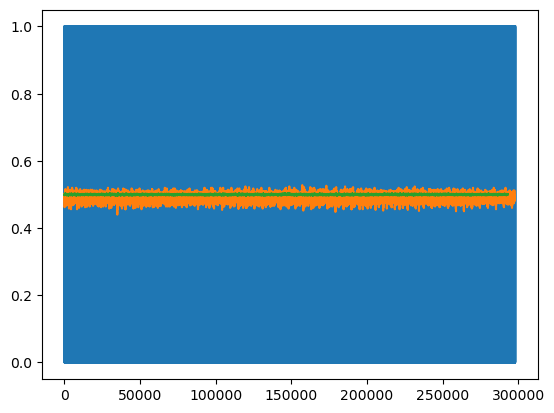

In [26]:
plt.plot(bit_list)
plt.plot(mv_sum(bit_list, 500))
plt.plot(mv_sum(bit_list, 5000))

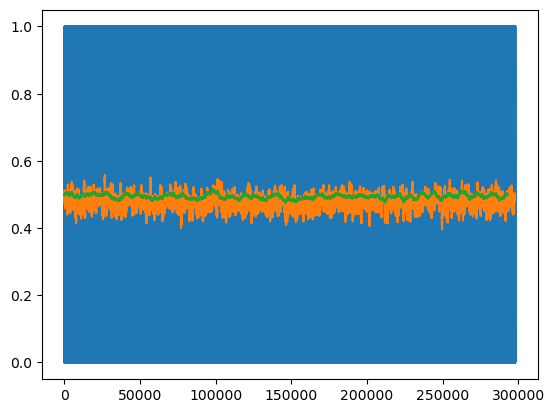

In [42]:
#Xor preprocessing

psudo_rand = [random.randint(0,1) for _ in range(len(bit_list))]
xor_bits = xor_preprocess(psudo_rand, bit_list)
str_xor_bits = [str(bits) for bits in xor_bits]
file_path = "./data/xor_bitstream.txt"
with open(file_path, 'w') as f:
    f.write("".join(str_xor_bits))
    f.close()

plt.plot(xor_bits)
plt.plot(mv_sum(xor_bits, 500))
plt.plot(mv_sum(xor_bits, 5000))

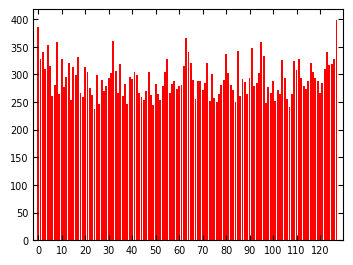

In [286]:
grplen = 8
numarr, freq = freq_num(bitstream, grplen)

fsize = 8
plt.figure(figsize=(4,3))
plt.bar(numarr, freq, color = 'red')
plt.xticks(np.arange(0,127,10))
plt.tick_params(axis="both", labelsize=fsize-1)
plt.tick_params(axis="both", direction="in", top=True, right=True, labelsize=fsize-1)
plt.xlim([-2,130])
plt.savefig("raw_fig/trn_8bit_dist.pdf")

Total No bits: 299200
Probability of generated bits: 0.5000


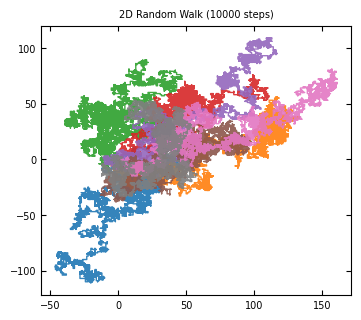

In [188]:
# random walk plot
bitstream = data_read_bin(folder+file_name1)[400:] + data_read_bin(folder+file_name2)[400:] 
bit_list = [int(b) for b in bitstream]
find_Prob(bitstream)
steps = 10000

fsize = 8
plt.figure(figsize=(4,3.5))
# random_walk_plot_1d(bit_list)
for i in range(10):
    if (i == 0 or i == 1): continue
    x,y = random_walk_plot_2d(bit_list[i*2*steps:(i+1)*2*steps])
    # Plot the path
    plt.title(f"2D Random Walk ({steps} steps)", fontsize = fsize-1)
    plt.plot(x, y, linewidth = 1, alpha = 0.9)
plt.tick_params(axis="both", labelsize=fsize-1)
plt.tick_params(axis="both", direction="in", top=True, right=True, labelsize=fsize-1)
plt.savefig("raw_fig/trn_rand_walk.pdf")

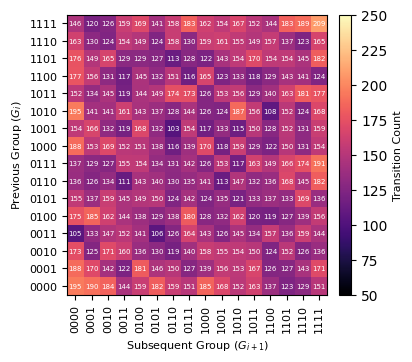

In [150]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar

grp = 4
pre_bit_grp, post_bit_grp = prevspost_bit_grp(bitstream, grp)
matrix, _ = transition_prob(pre_bit_grp, post_bit_grp)
labels = [format(i, f'0{grp}b') for i in range(2**grp)]

fig = plt.figure(figsize=(4, 3.5))
ax_main = fig.add_axes([0.1, 0.1, 0.65, 0.8])  # Main plot
ax_cbar = fig.add_axes([0.78, 0.1, 0.03, 0.8])  # Colorbar

X, Y = np.meshgrid(np.arange(matrix.shape[1]+1), np.arange(matrix.shape[0]+1))
cmap = plt.get_cmap('magma')
norm = mcolors.Normalize(vmin=50, vmax=250)
mesh = ax_main.pcolormesh(X, Y, matrix, cmap=cmap, norm=norm, shading='auto')

# Manually create colorbar
cb = mcolorbar.ColorbarBase(ax_cbar, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label('Transition Count', fontsize=8)

# Set ticks and labels on main plot
ax_main.set_xticks(np.arange(2**grp) + 0.5)
ax_main.set_yticks(np.arange(2**grp) + 0.5)
ax_main.set_xticklabels(labels, rotation=90, fontsize=8)
ax_main.set_yticklabels(labels, fontsize=8)
ax_main.set_xlabel('Subsequent Group ($G_{i+1}$)', fontsize=8)
ax_main.set_ylabel('Previous Group ($G_i$)', fontsize=8)

# Annotate each cell
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax_main.text(j + 0.5, i + 0.5, f'{matrix[i, j]:.0f}', ha='center', va='center', color='white', fontsize=5)

plt.savefig('raw_fig/trn_trans_cnt.pdf')
plt.show()


In [231]:
import numpy as np
from statsmodels.tsa.stattools import acf

def spatial_acf_test_from_bits(bits, nlags=40, alpha=0.05):
    """
    Perform spatial autocorrelation test on a sequence of random bits (0s and 1s).

    Parameters:
        bits (list or array-like): Sequence of bits (0s and 1s).
        nlags (int): Number of lags to compute ACF for.
        alpha (float): Significance level (default = 0.05 for 95% CI).

    Returns:
        dict:
            'acf_values': List of autocorrelation values.
            'confint': Confidence intervals for each lag.
            'lags': List of lag indices.
            'passed': True if no significant autocorrelation found.
            'significant_lags': List of lags with significant autocorrelation.
    """
    bits = np.asarray(bits)

    if not np.all(np.isin(bits, [0, 1])):
        raise ValueError("Input sequence must contain only 0s and 1s.")

    # Convert bits: 0 → -1, 1 → +1
    normalized = 2 * bits - 1
    normalized = normalized - np.mean(normalized)

    # Compute ACF and confidence intervals
    acf_vals, confint, qstat, pvals = acf(
        normalized, nlags=nlags, alpha=alpha, qstat=True, fft=True
    )

    # Check for significant autocorrelation (excluding lag 0)
    significant_lags = []
    for lag in range(1, nlags + 1):
        lower, upper = confint[lag]
        if acf_vals[lag] < lower or acf_vals[lag] > upper:
            significant_lags.append(lag)

    return {
        "acf_values": acf_vals,
        "confint": confint,
        "lags": list(range(nlags + 1)),
        "passed": len(significant_lags) == 0,
        "significant_lags": significant_lags
    }


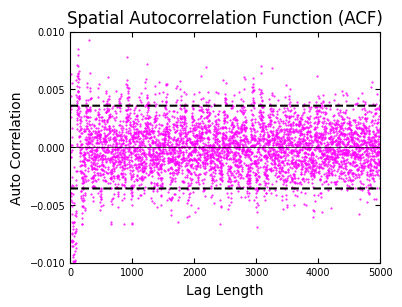

In [289]:
lag_len = 5000
result = spatial_acf_test_from_bits(bit_list,lag_len)
acf_vals = result["acf_values"]
confint = result["confint"]
lags = result["lags"]
conf_bound = 1.96/np.sqrt(len(bit_list))
plt.figure(figsize=(4, 3))
plt.plot(lags[2:], acf_vals[2:], "o", ms = 0.5, color = 'magenta')
plt.plot(lags[2:], np.ones(len(lags[2:]))*conf_bound, "--", c = "black")
plt.plot(lags[2:], -np.ones(len(lags[2:]))*conf_bound, "--", c = "black")
# plt.fill_between(lags, confint[:, 0], confint[:, 1], color='gray', alpha=0.3)
plt.axhline(0, color='black', linewidth=0.5)
# plt.yscale("log")
plt.xlabel('Lag Length')
plt.ylabel('Auto Correlation')
plt.title('Spatial Autocorrelation Function (ACF)')

plt.yticks(np.arange(-0.01,0.015, 0.005))
plt.tick_params(axis="both", labelsize=fsize-1)
plt.tick_params(axis="both", direction="in", top=True, right=True, labelsize=fsize-1)
plt.xlim([0,lag_len])
plt.ylim([-0.01, 0.01])

plt.savefig('raw_fig/trn_acf.pdf')

Random walk experiment with bits generated from code

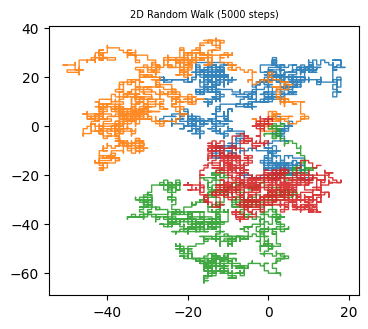

In [114]:
def gen_rand(p, n):
    nums = np.random.uniform(0, 1, n)
    bits = [1 if b >= p else 0 for b in nums]
    return bits

# random walk plot
rep = 4
plt.figure(figsize=(4,3.5))
for i in range(rep):
    steps = 5000
    bit_list = gen_rand(0.5, steps)

    fsize = 8
    x,y = random_walk_plot_2d(bit_list)
    # Plot the path
    plt.title(f"2D Random Walk ({steps} steps)", fontsize = fsize-1)
    plt.plot(x, y, linewidth = 1, alpha = 0.9)
